# Netflix Data Analysis

###      STEP 1: Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### STEP 2: Loading the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns") # df.shape = returns a tuple in the form of (rows,columns)

✅ Dataset loaded successfully!
Shape: 8797 rows × 14 columns


### STEP 3: Data Exploration

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Unkown,NaN,united states,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unkown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Unkown,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unkown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unkown,NaN,unkown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unkown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added'],
      dtype='object')

In [5]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added        0
release_year      0
rating            4
duration          3
listed_in         0
description       0
year_added        0
month_added       0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          7972 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8793 non-null   object
 9   duration      8794 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
 12  year_added    8797 non-null   int64 
 13  month_added   8797 non-null   int64 
dtypes: int64(3), object(11)
memory usage: 962.3+ KB


### Date Column Conversion and Validation

The `date_added` column is initially stored as an **object (string)** data type. For accurate date-based analysis and feature engineering, it is converted to the **datetime** format using `pd.to_datetime()`. The `errors='coerce'` parameter ensures that any invalid date values are safely converted to `NaT` instead of raising an error.

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')

In [8]:
df['date_added'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8797 entries, 0 to 8796
Series name: date_added
Non-Null Count  Dtype         
--------------  -----         
8797 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 68.9 KB


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          7972 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8793 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
 12  year_added    8797 non-null   int64         
 13  month_added   8797 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(10)
memory usage: 962.3+ KB


### Handling Missing Values 

#### 1. cast (825 missing values)

In [10]:
df['cast'] = df['cast'].fillna('Not Available')

In [11]:
print(f"Missing Values in cast column is : {df['cast'].isnull().sum()}")

Missing Values in cast column is : 0


#### 2. rating (4 missing values)

In [12]:
df['rating'].mode()

0    TV-MA
Name: rating, dtype: object

In [13]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [14]:
df['rating']

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8792        R
8793    TV-Y7
8794        R
8795       PG
8796    TV-14
Name: rating, Length: 8797, dtype: object

#### 3. duration (3 missing values)

In [15]:
df['duration'].mode()

0    1 Season
Name: duration, dtype: object

In [16]:
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [17]:
df.isnull().sum()
# Now we can see there is no null values present in the df

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

### Checking Duplicates

In [18]:
print("Number of duplicates in the DataFrame is : ",df.duplicated().sum())

Number of duplicates in the DataFrame is :  0


### Descriptive Statistics

The `describe()` function provides a statistical summary of the dataset. For numerical columns, it returns key statistics such as:

- **Count** – Number of non-null values
- **Mean** – Average value
- **Standard Deviation (`std`)** – Measure of data dispersion
- **Minimum (`min`)** – Smallest value
- **25%, 50%, 75%** – Quartiles (Q1, Median, and Q3)
- **Maximum (`max`)** – Largest value

These statistics help in understanding the distribution, central tendency, and spread of the data.

In [19]:
df.describe()

,date_added,release_year,year_added,month_added
count,8797,8797.000000,8797.000000,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472,2018.871888,6.654996
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,7.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,10.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000
std,NaN,8.822191,1.574243,3.436554


### STEP 4: DATA Preprocessing

#### Removing Columns that are not neccessary

In [20]:
df['director'].value_counts()

director
Unkown    8797
Name: count, dtype: int64

In [21]:
df.drop('director', axis=1, inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   cast          8797 non-null   object        
 4   country       8797 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8797 non-null   int64         
 7   rating        8797 non-null   object        
 8   duration      8797 non-null   object        
 9   listed_in     8797 non-null   object        
 10  description   8797 non-null   object        
 11  year_added    8797 non-null   int64         
 12  month_added   8797 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 893.6+ KB


In [23]:
df.drop('description', axis=1, inplace=True)

### Dropping Irrelevant Columns

To improve the quality and efficiency of the analysis, columns that do not contribute meaningful insights to the Exploratory Data Analysis (EDA) have been removed.

### Columns Removed

- **`director`**: This column contained only the value **"Unknown"** for all records, providing no variability or useful information for analysis. Since it could not be used for grouping, comparison, or visualization, it was removed.

- **`description`**: This column consists of textual summaries of movies and TV shows. As the scope of this project focuses on numerical and categorical EDA rather than Natural Language Processing (NLP), it was excluded from the analysis.

Removing these columns simplifies the dataset, reduces unnecessary memory usage, and allows the analysis to focus on features that provide meaningful business insights.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   cast          8797 non-null   object        
 4   country       8797 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8797 non-null   int64         
 7   rating        8797 non-null   object        
 8   duration      8797 non-null   object        
 9   listed_in     8797 non-null   object        
 10  year_added    8797 non-null   int64         
 11  month_added   8797 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 824.8+ KB


In [25]:
df.sample()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,year_added,month_added
5993,s5994,Movie,17 Again,"Zac Efron, Leslie Mann, Matthew Perry, Thomas ...",united states,2021-01-01,2009,PG-13,102 min,Comedies,2021,1


### Splitting and Exploding the `listed_in` Column

The `listed_in` column contains multiple genres separated by commas for a single title. To perform genre-wise analysis accurately, the column is first split into a list of individual genres and then exploded so that each row represents a single genre associated with a movie or TV show. This transformation enables accurate counting, filtering, and visualization of genre distributions.

In [26]:
df[['listed_in']].head(5)

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."


In [27]:
# Split genres into a list
df['listed_in'] = df['listed_in'].str.split(', ')

# Create one row for each genre
df = df.explode('listed_in')

# Reset index 
df.reset_index(drop=True, inplace=True)

In [28]:
df[['title', 'listed_in']].head(10)

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows
5,Ganglands,International TV Shows
6,Ganglands,TV Action & Adventure
7,Jailbirds New Orleans,Docuseries
8,Jailbirds New Orleans,Reality TV
9,Kota Factory,International TV Shows


### Converting the `listed_in` Column to Category Data Type

After splitting and exploding the `listed_in` column, each row now represents a single genre. Since genres belong to a fixed set of repeated categories, the column is converted to the **category** data type. This optimization reduces memory usage and improves the efficiency of categorical operations such as grouping, filtering, and visualization.

In [29]:
df['listed_in'] = df['listed_in'].astype('category')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19303 entries, 0 to 19302
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       19303 non-null  object        
 1   type          19303 non-null  object        
 2   title         19303 non-null  object        
 3   cast          19303 non-null  object        
 4   country       19303 non-null  object        
 5   date_added    19303 non-null  datetime64[ns]
 6   release_year  19303 non-null  int64         
 7   rating        19303 non-null  object        
 8   duration      19303 non-null  object        
 9   listed_in     19303 non-null  category      
 10  year_added    19303 non-null  int64         
 11  month_added   19303 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(3), object(7)
memory usage: 1.6+ MB


In [31]:
df.nunique()

show_id         8797
type               2
title           8797
cast            7683
country          749
date_added      1714
release_year      74
rating            17
duration         220
listed_in         42
year_added        14
month_added       12
dtype: int64

### STEP 5: DATA Visualization

In [34]:
sns.set_theme(style="whitegrid", palette="deep")

#### Q. What is the most favourite Genre of movies released on Netflix?

In [35]:
df['listed_in'].describe()

count                    19303
unique                      42
top       International Movies
freq                      2752
Name: listed_in, dtype: object

In [40]:
df['listed_in'].value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

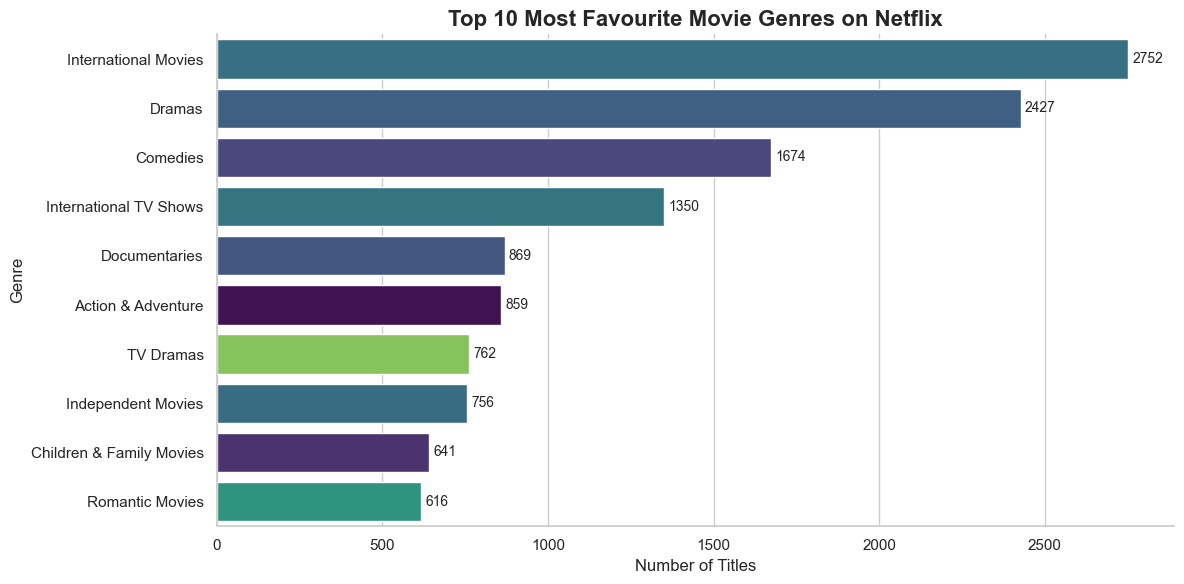

In [44]:
plt.figure(figsize=(12,6))

ax = sns.countplot(data=df, y='listed_in', order=df['listed_in'].value_counts().head(10).index, hue='listed_in', palette='viridis', legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Top 10 Most Favourite Movie Genres on Netflix", fontsize=16, fontweight='bold')

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

sns.despine()
plt.tight_layout()
plt.show()

### `📊 Analysis: Top 10 Most Favourite Movie Genres on Netflix

This visualization highlights the **Top 10 most frequently available movie genres** on Netflix based on the number of titles in each genre.

### 🔍 Key Insights

- **`International Movies`** is the most dominant genre on Netflix, with **`2,752 titles`**, indicating Netflix's strong focus on globally diverse content.
- **`Dramas (2,427)`** and **`Comedies (1,674)`** are the second and third most common genres, showing that these genres remain highly popular among viewers.
- **`International TV Shows (1,350)`** also have a significant presence, reflecting Netflix's investment in non-English television content.
- **`Documentaries`** and **A`ction & Adventure`** occupy the middle positions, suggesting a balanced catalog catering to educational and action-oriented audiences.
- Genres such as **`TV Dramas`**, **`Independent Movies`**, **`Children & Family Movies`**, and **`Romantic Movies`** have comparatively fewer titles but still represent important categories in Netflix's library.
- Overall, the distribution indicates that Netflix prioritizes **`international, drama, and comedy content`**, while maintaining a diverse collection across multiple genres to appeal to a broad global audience.`

### Q. Which year had the highest number of movies added to Netflix?

In [49]:
df['year_added'].value_counts()

year_added
2019    4507
2020    4162
2018    3671
2021    3268
2017    2593
2016     858
2015     152
2014      37
2013      23
2011      19
2012       4
2008       4
2009       3
2010       2
Name: count, dtype: int64

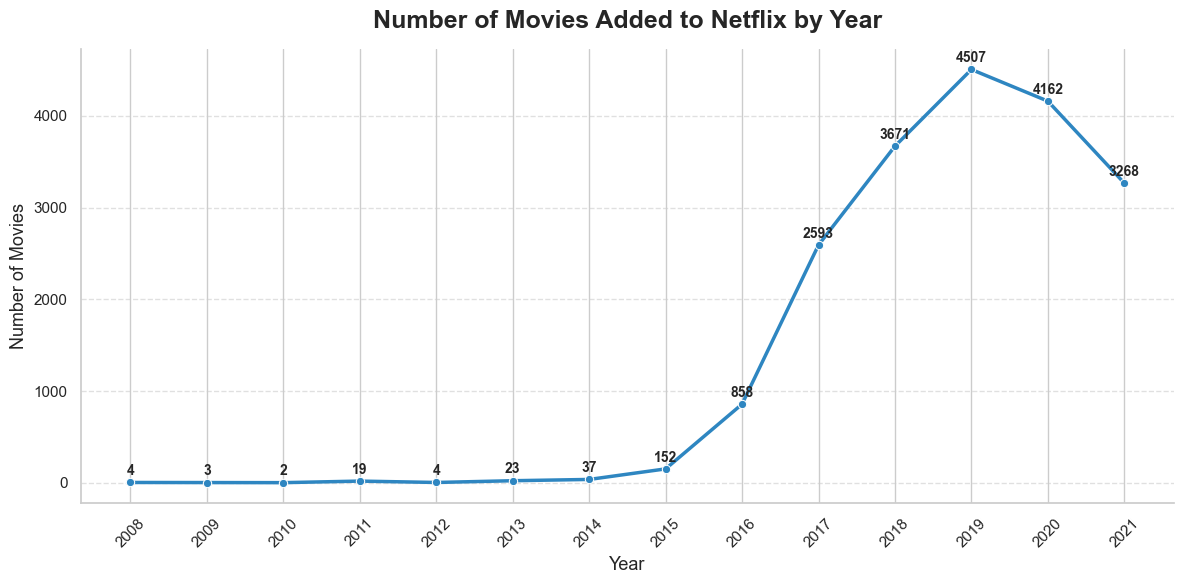

In [48]:
# Count movies added each year
year_counts = (df['year_added'].value_counts().sort_index())

plt.figure(figsize=(12, 6))

ax = sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', linewidth=2.5, color='#2E86C1')

# Add value labels
for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y + 80, str(y), ha='center', fontsize=10, fontweight='bold')

plt.title("Number of Movies Added to Netflix by Year", fontsize=18, fontweight='bold', pad=15)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)

plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

sns.despine()
plt.tight_layout()
plt.show()

### 📈 Analysis: Number of Movies Added to Netflix by Year

This line chart illustrates the yearly trend of movies added to Netflix between **2008 and 2021**.

### 🔍 Key Insights

- **2019** recorded the highest number of movies added to Netflix, with **4,507 titles**, making it the platform's most active year for content additions.
- There was a **consistent upward trend** in the number of movies added from **2015 to 2019**, indicating a period of rapid expansion in Netflix's content library.
- The most significant growth occurred between **2016 and 2017**, where the number of movies increased from **858 to 2,593**, reflecting a major increase in content acquisition and production.
- After reaching its peak in **2019**, the number of movies added **declined slightly** to **4,162 in 2020** and **3,268 in 2021**.
- The years **2008–2014** show very few additions, suggesting that Netflix's movie catalog was relatively limited during its early years compared to its later expansion.
- Overall, the visualization highlights Netflix's rapid growth in movie additions from **2015 onward**, with **2019 serving as the peak year** before a gradual decline in subsequent years.